In [1]:
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages


class State(TypedDict):
    # 메시지 정의(list type 이며 add_messages 함수를 사용하여 메시지를 추가)
    messages: Annotated[list, add_messages]


In [3]:
from typing import TypedDict, Annotated, List
from langgraph.graph import StateGraph, END

# 1. State 정의 (우리 챗봇의 기억 공간)
class TravelState(TypedDict):
    question: str          # 사용자 질문
    documents: List[str]   # RAG 검색 결과
    answer: str            # 최종 답변
    needs_search: bool     # 검색 필요 여부 판단 (Router 결과)

# 2. Node 정의 (실제 작업 함수들)
def router_node(state: TravelState):
    # LLM에게 물어봅니다: "이거 검색 필요해?"
    # 여기서는 예시로 무조건 검색한다고 가정
    print("🤖 [판단 중]: 검색이 필요한가? -> YES")
    return {"needs_search": True}

def retriever_node(state: TravelState):
    print("🔎 [검색 중]: 여행 정보를 찾습니다...")
    # 여기서 Vector DB 검색 수행
    return {"documents": ["오사카 맛집 A", "오사카 호텔 B"]}

def persona_chat_node(state: TravelState):
    print("💬 [답변 생성]: SFT 모델이 답변을 만듭니다...")
    # SFT 모델에 (질문 + 문서) 넣고 답변 생성
    return {"answer": "오사카 맛집으로는 A가 정말 좋아요! (여행 친구 말투)"}

# 3. Graph 조립 (설계도 그리기)
workflow = StateGraph(TravelState)

# 노드 등록
workflow.add_node("router", router_node)
workflow.add_node("retriever", retriever_node)
workflow.add_node("chatbot", persona_chat_node)

# 4. Edge 연결 (흐름 제어)
workflow.set_entry_point("router") # 시작점

# 조건부 엣지 함수
def where_to_go(state):
    if state["needs_search"]:
        return "retriever" # 검색 필요하면 검색 노드로
    else:
        return "chatbot"   # 아니면 바로 답변

workflow.add_conditional_edges(
    "router",
    where_to_go,
    {"retriever": "retriever", "chatbot": "chatbot"} # 경로 맵핑
)

workflow.add_edge("retriever", "chatbot") # 검색 끝나면 답변 생성으로
workflow.add_edge("chatbot", END)         # 답변 끝나면 종료

# 5. 컴파일 (실행 가능한 앱으로 변환)
app = workflow.compile()

In [19]:
from dotenv import load_dotenv

load_dotenv(override=True)

True

### Model
- Agent의 추론 엔진
- provider:model 형식의 문자열로 모델 지정

In [31]:
from langchain.chat_models import init_chat_model

model = init_chat_model("openai:gpt-5-nano")


In [21]:
from langchain_openai import ChatOpenAI

model = ChatOpenAI(
    model="gpt-5-nano",
    temperature=0.1,  # 응답의 무작위성 제어
    max_tokens=1000,  # 최대 생성 토큰 수
    timeout=30,  # 요청 타임아웃(초)
)

#### invoke()
- 모델의 응답을 받는 방법
- synchronous 방식으로 동작

In [22]:
messages = [
    ("system", "You are a helpful assistant."),
    ("human", "대한민국의 수도는 어디야?"),
]

response = model.invoke(messages)
print(response)

content='대한민국의 수도는 서울(서울특별시)입니다.' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 215, 'prompt_tokens': 24, 'total_tokens': 239, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 192, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-D26Kv4ELTxCZ1oQSfcSaJD36LvSp7', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019bf810-6c51-7df1-8f9d-9e2d6defb7cb-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 24, 'output_tokens': 215, 'total_tokens': 239, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 192}}


In [25]:
### .content
# 모델이 생성한 텍스트 답변
response.content

'대한민국의 수도는 서울(서울특별시)입니다.'

In [ ]:
### .usage_metadata
# 토큰 사용량 정보
# 입력 토큰(input_tokens), 출력 토큰(output_tokens)
response.usage_metadata

{'input_tokens': 24,
 'output_tokens': 215,
 'total_tokens': 239,
 'input_token_details': {'audio': 0, 'cache_read': 0},
 'output_token_details': {'audio': 0, 'reasoning': 192}}

In [28]:
### .response_metadata
# 응답의 상세 정보 제공
response.response_metadata

{'token_usage': {'completion_tokens': 215,
  'prompt_tokens': 24,
  'total_tokens': 239,
  'completion_tokens_details': {'accepted_prediction_tokens': 0,
   'audio_tokens': 0,
   'reasoning_tokens': 192,
   'rejected_prediction_tokens': 0},
  'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}},
 'model_provider': 'openai',
 'model_name': 'gpt-5-nano-2025-08-07',
 'system_fingerprint': None,
 'id': 'chatcmpl-D26Kv4ELTxCZ1oQSfcSaJD36LvSp7',
 'service_tier': 'default',
 'finish_reason': 'stop',
 'logprobs': None}

In [32]:
### .stream()
# 답변 방식을 변경 - streaming 방식
for chunk in model.stream(messages):
    print(chunk.content, end="")

서울(서울특별시)입니다.

In [33]:
response = model.ainvoke(messages)
await response

AIMessage(content='대한민국의 수도는 서울특별시(일반적으로 서울)입니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 154, 'prompt_tokens': 24, 'total_tokens': 178, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 128, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-D26OJ3fmVrHeTvUZ9tR0NkmuDmUMK', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019bf813-8d18-7190-b58d-2d6ccedfff7a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 24, 'output_tokens': 154, 'total_tokens': 178, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 128}})

In [34]:
async for chunk in model.astream(messages):
    print(chunk.content, end="")

대한민국의 수도는 서울(서울특별시)입니다.

In [ ]:
### vllm과 연결
# vLLM 예시
# model = ChatOpenAI(
#     base_url="http://localhost:8000/v1",
#     api_key="EMPTY",
#     model="meta-llama/Llama-2-7b-chat-hf",
#     extra_body={"use_beam_search": True, "best_of": 4}
# )

In [35]:
from langchain.chat_models import init_chat_model
from langchain.messages import HumanMessage, AIMessage, SystemMessage

system_msg = SystemMessage("당신은 친절한 Assistant입니다.")
human_msg = HumanMessage("안녕하세요. 반갑습니다.")

messages = [system_msg, human_msg]
response = model.invoke(messages)  # AIMessage 반환
response

AIMessage(content='안녕하세요! 반갑습니다. 무엇을 도와드릴까요? 정보 찾기, 글쓰기나 번역, 문제 해결, 아이디어 뇌짬 등 필요한 게 있으면 말씀해 주세요. 어떤 주제로 이야기해볼까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 380, 'prompt_tokens': 26, 'total_tokens': 406, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 320, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-D26Qo4YnQkU9f1yvIe5wqvsTKqVww', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019bf815-fd73-7a40-b887-50d2a2fa8955-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 26, 'output_tokens': 380, 'total_tokens': 406, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 320}})

In [36]:
print(response.content)

안녕하세요! 반갑습니다. 무엇을 도와드릴까요? 정보 찾기, 글쓰기나 번역, 문제 해결, 아이디어 뇌짬 등 필요한 게 있으면 말씀해 주세요. 어떤 주제로 이야기해볼까요?


In [37]:
from langchain.messages import SystemMessage, HumanMessage, AIMessage

messages = [
    SystemMessage("당신은 친절한 어시스턴트입니다."),
    HumanMessage("대한민국의 수도는?"),
    AIMessage("대한민국의 수도는 서울입니다."),
    HumanMessage("영어로 작성해줘."),
]

response = model.invoke(messages)
print(response.content)

The capital of South Korea is Seoul.


In [38]:
messages = [
    {"role": "system", "content": "당신은 친절한 어시스턴트입니다."},
    {"role": "user", "content": "대한민국의 수도는?"},
    {"role": "assistant", "content": "대한민국의 수도는 서울입니다."},
    {"role": "user", "content": "영어로 작성해줘."},
]

response = model.invoke(messages)
print(response.content)

The capital of South Korea is Seoul.


#### Message 유형
- SystemMessage: 모델의 동작 방식과 역할을 정의
    - 대확 시작 시 모델 행동 지침 설정
- HumanMessage: 사용자 입력을 나타냄
    - 사용자의 질문이나 요청 전달
- AIMessage: 모델이 생성한 응답
    - 이전 응답 기록 유지, 도구 호출 정보 포함
- ToolMessage: 도구 호출의 결과
    - 도구 실행 결과를 모델에 전달

In [39]:
system_msg = SystemMessage("You are a helpful python coding assistant.")
messages = [system_msg, HumanMessage("로또 번호 추첨 코드를 작성해줘.")]

response = model.invoke(messages)
print(response.content)

다음은 파이썬으로 로또 번호를 추첨하는 예제 코드입니다. 기본은 6/45 형태이며, 보너스 번호 포함 여부도 옵션으로 제공합니다. 필요에 따라 추첨 수, 한 게임당 숫자 수, 최대 숫자 등을 조정할 수 있습니다.

```python
import random
from typing import List, Dict, Optional

def generate_lotto(draws: int = 1,
                   numbers: int = 6,
                   max_number: int = 45,
                   include_bonus: bool = False,
                   sort_numbers: bool = True,
                   seed: Optional[int] = None):
    """
    로또 번호를 여러 번 추첨합니다.
    - draws: 생성할 추첨 수
    - numbers: 한 게임당 뽑을 숫자 수
    - max_number: 후보 번호의 최댓값(1..max_number)
    - include_bonus: 보너스 번호 포함 여부
    - sort_numbers: 숫자 오름차순 정렬 여부
    - seed: 난수 시드
    반환: 리스트 형태의 결과. 각 요소는 dict 형태로 {'numbers': [...], 'bonus': ...} (보너스 포함 여부에 따라 다름)
    """
    if numbers < 1:
        raise ValueError("numbers는 1 이상이어야 합니다.")
    if max_number < numbers:
        raise ValueError("max_number는 numbers보다 커야 합니다.")
    if include_bonus and max_number <= numbers:
        raise ValueError("보너스 번호를 포함하려면 max_numb

In [ ]:
### HumanMessage
# 메타데이터 추가
human_msg = HumanMessage(
    content="안녕하세요? 반가워요",
    name="teddy",  # 선택사항: 다른 사용자 식별
    id="abc123",  # 선택사항: 추적을 위한 고유 식별자
)

In [40]:
### AIMessage
# 모델 호출의 출력을 의미
# 대화 이력 유지 시, 이전 응답을 AIMessage로 포함 -> 이전 발화를 인식함

response = model.invoke("대한민국의 수도는?")
print(f"Type: {type(response)}")
print(f"Content: {response.content}")

Type: <class 'langchain_core.messages.ai.AIMessage'>
Content: 서울(서울특별시)입니다.


In [43]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

In [44]:
class InternalState(TypedDict):
    input: str  # 입력값
    result: str  # 처리 결과

# StateGraph 인스턴스 생성 (State 타입을 매개변수로 전달)
builder = StateGraph(InternalState)

# 노드 함수 정의: 현재 상태를 받아 업데이트할 값을 딕셔너리로 반환
def process_node(state: InternalState):
    return {"result": f"처리됨: {state['input']}"}

# 노드 추가: 이름과 함수를 매핑
builder.add_node("process", process_node)

# 엣지 추가: START에서 process로, process에서 END로
builder.add_edge(START, "process")
builder.add_edge("process", END)

# 컴파일: 실행 가능한 그래프로 변환
graph = builder.compile()

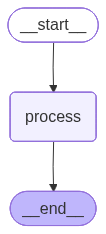

In [45]:
graph

In [47]:
result = graph.invoke({"input": "안녕하세요"})
print(result)

{'input': '안녕하세요', 'result': '처리됨: 안녕하세요'}


In [49]:
from typing_extensions import TypedDict

class BasicState(TypedDict):
    name: str
    age: int
    messages: list[str]

In [50]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END


# 리듀서를 지정하지 않은 기본 State (덮어쓰기 동작)
class State(TypedDict):
    foo: int  # 정수형 필드
    bar: str  # 문자열 필드


def node_1(state: State):
    """첫 번째 노드: foo 값을 2로 업데이트"""
    print(f"node_1 - 현재 상태: {state}")
    return {"foo": 2}  # foo만 업데이트 (bar는 유지)


def node_2(state: State):
    """두 번째 노드: bar 값을 '안녕'으로 업데이트"""
    print(f"node_2 - 현재 상태: {state}")
    return {"bar": "안녕"}  # bar만 업데이트 (foo는 유지)


# 그래프 빌더 생성
builder = StateGraph(State)

# 노드 추가
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)

# 엣지 추가: START → node_1 → node_2 → END
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_2", END)

# 컴파일 및 실행
graph = builder.compile()

# 초기 상태로 그래프 실행
result = graph.invoke({"foo": 1, "bar": "반가워"})
print(f"최종 결과: {result}")

node_1 - 현재 상태: {'foo': 1, 'bar': '반가워'}
node_2 - 현재 상태: {'foo': 2, 'bar': '반가워'}
최종 결과: {'foo': 2, 'bar': '안녕'}


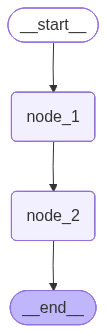

In [51]:
graph

In [52]:
from typing import Annotated
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage, HumanMessage, AIMessage
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END


# add_messages 리듀서를 사용한 메시지 상태 정의
class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]  # 메시지 리스트 (자동 병합)


def chatbot_node(state: MessagesState):
    """챗봇 노드: 마지막 메시지에 응답 생성"""
    last_message = state["messages"][-1]  # 마지막 메시지 추출
    response = f"메시지를 받았습니다: {last_message.content}"
    return {"messages": [AIMessage(content=response)]}  # AI 응답 반환


# 그래프 구성
builder = StateGraph(MessagesState)
builder.add_node("chatbot", chatbot_node)
builder.add_edge(START, "chatbot")
builder.add_edge("chatbot", END)

graph = builder.compile()

# HumanMessage로 대화 시작
result = graph.invoke({"messages": [HumanMessage(content="안녕하세요!")]})

# 결과 출력
print("메시지 목록:")
for msg in result["messages"]:
    print(f"- {msg.__class__.__name__}: {msg.content}")

메시지 목록:
- HumanMessage: 안녕하세요!
- AIMessage: 메시지를 받았습니다: 안녕하세요!


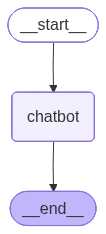

In [54]:
graph

In [55]:
from typing import TypedDict, Annotated, List
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage
from dotenv import load_dotenv

# 0. 환경설정 로드 (.env)
load_dotenv()

# 1. State 정의
class State(TypedDict):
    # 대화 내용을 계속 쌓아주는 마법의 리스트
    messages: Annotated[List, add_messages]

# 2. Node 정의
def bot_node(state: State):
    print("챗봇이 생각 중입니다...")
    return {"messages": [model.invoke(state["messages"])]}

# 3. Graph 만들기
builder = StateGraph(State)
builder.add_node("chatbot", bot_node)
builder.add_edge(START, "chatbot")
builder.add_edge("chatbot", END)

# 4. 컴파일
graph = builder.compile()

# 5. 실행 테스트
print("--- 여행 챗봇 테스트 ---")
initial_input = {"messages": [HumanMessage(content="안녕! 넌 누구야?")]}

# stream을 쓰면 과정을 볼 수 있습니다.
for event in graph.stream(initial_input):
    for key, value in event.items():
        print(f"\n[노드 완료: {key}]")
        print(f"답변: {value['messages'][-1].content}")

--- 여행 챗봇 테스트 ---
챗봇이 생각 중입니다...

[노드 완료: chatbot]
답변: 안녕! 나는 ChatGPT야. OpenAI가 만든 대화형 인공지능으로, GPT-4 기반으로 작동해. 한국어로도 자연스럽게 대화할 수 있고, 글쓰기나 공부 도와주기, 아이디어 브레인스토밍, 코딩, 번역, 요리법 정리, 정보 정리 등 다양한 일을 도와줄 수 있어. 다만 최신 뉴스나 인터넷 실시간 검색은 안 되고, 개인 정보도 알지 못해. 무엇이 필요해? 어떤 주제로 대화해볼까?


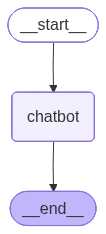

In [56]:
graph

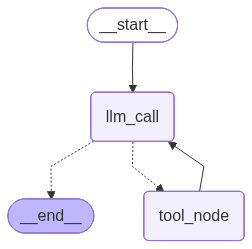

================================ Human Message =================================

Add 3 and 4.
================================== Ai Message ==================================
Tool Calls:
  add (call_XrMNy7OHvYe2Pgviwk0ZnOms)
 Call ID: call_XrMNy7OHvYe2Pgviwk0ZnOms
  Args:
    a: 3
    b: 4
================================= Tool Message =================================

7
================================== Ai Message ==================================

3 + 4 = 7


In [57]:
# Step 1: Define tools and model

from langchain.tools import tool
from langchain.chat_models import init_chat_model

# Define tools
@tool
def multiply(a: int, b: int) -> int:
    """Multiply `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a * b


@tool
def add(a: int, b: int) -> int:
    """Adds `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a + b


@tool
def divide(a: int, b: int) -> float:
    """Divide `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a / b


# Augment the LLM with tools
tools = [add, multiply, divide]
tools_by_name = {tool.name: tool for tool in tools}
model_with_tools = model.bind_tools(tools)

# Step 2: Define state

from langchain.messages import AnyMessage
from typing_extensions import TypedDict, Annotated
import operator


class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]
    llm_calls: int

# Step 3: Define model node
from langchain.messages import SystemMessage


def llm_call(state: dict):
    """LLM decides whether to call a tool or not"""

    return {
        "messages": [
            model_with_tools.invoke(
                [
                    SystemMessage(
                        content="You are a helpful assistant tasked with performing arithmetic on a set of inputs."
                    )
                ]
                + state["messages"]
            )
        ],
        "llm_calls": state.get('llm_calls', 0) + 1
    }


# Step 4: Define tool node

from langchain.messages import ToolMessage


def tool_node(state: dict):
    """Performs the tool call"""

    result = []
    for tool_call in state["messages"][-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))
    return {"messages": result}

# Step 5: Define logic to determine whether to end

from typing import Literal
from langgraph.graph import StateGraph, START, END


# Conditional edge function to route to the tool node or end based upon whether the LLM made a tool call
def should_continue(state: MessagesState) -> Literal["tool_node", END]:
    """Decide if we should continue the loop or stop based upon whether the LLM made a tool call"""

    messages = state["messages"]
    last_message = messages[-1]

    # If the LLM makes a tool call, then perform an action
    if last_message.tool_calls:
        return "tool_node"

    # Otherwise, we stop (reply to the user)
    return END

# Step 6: Build agent

# Build workflow
agent_builder = StateGraph(MessagesState)

# Add nodes
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", tool_node)

# Add edges to connect nodes
agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    ["tool_node", END]
)
agent_builder.add_edge("tool_node", "llm_call")

# Compile the agent
agent = agent_builder.compile()


from IPython.display import Image, display
# Show the agent
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

# Invoke
from langchain.messages import HumanMessage
messages = [HumanMessage(content="Add 3 and 4.")]
messages = agent.invoke({"messages": messages})
for m in messages["messages"]:
    m.pretty_print()

In [61]:
from typing import TypedDict, Annotated, List
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage
from dotenv import load_dotenv

# State 정의
class State(TypedDict):
    # 대화 내용을 계속 쌓아주는 마법의 리스트
    messages: Annotated[List, add_messages]
    context: str

#retriever = vectorstore.as_retriever()
# Node
def bot_node(state: State):
    print("🤖 챗봇이 생각 중입니다...")
    return {"messages": [model.invoke(state["messages"])]}

def retrieve_node(state: State):
    print("[검색]: 관련 정보를 찾는 중...")

    last_message = state["messages"][-1]
    query = last_message.content

    docs = retriever.invoke(query)
    context_text = "\n\n".join([doc.page_content for doc in docs])

    return {"context": context_text}

# Graph
builder = StateGraph(State)
builder.add_node("chatbot", bot_node)
builder.add_edge(START, "chatbot")
builder.add_edge("chatbot", END)

graph = builder.compile()

# test
print("--- 여행 챗봇 테스트 ---")
initial_input = {"messages": [HumanMessage(content="안녕! 넌 누구야?")]}

# stream을 쓰면 과정을 볼 수 있습니다.
for event in graph.stream(initial_input):
    for key, value in event.items():
        print(f"\n[노드 완료: {key}]")
        print(f"답변: {value['messages'][-1].content}")

--- 여행 챗봇 테스트 ---
🤖 챗봇이 생각 중입니다...

[노드 완료: chatbot]
답변: 안녕하세요! 저는 ChatGPT라는 OpenAI의 대화형 인공지능이에요. 사람과 자연스럽게 대화하고, 질문에 답하거나 글을 쓰는 데 도움을 주고, 아이디어를 함께 생각해주고, 번역·요약, 간단한 코딩 문제까지 도와줄 수 있습니다. 다만 인터넷을 실시간으로 검색하진 못하고, 제 지식은 2024년 6월까지의 정보에 기반해요. 무엇이든 궁금한 점이나 필요하신 도움을 말씀해 주시면 최선을 다해 도와드릴게요. 지금 무엇부터 해볼까요?


In [64]:
workflow = StateGraph(State)

# 노드 등록
workflow.add_node("retriever", retrieve_node)
workflow.add_node("chatbot", chatbot_node)

# 엣지 연결 (순서 정하기)
# 1. 시작하면 무조건 검색부터 한다
workflow.add_edge(START, "retriever") 

# 2. 검색이 끝나면 챗봇에게 넘긴다
workflow.add_edge("retriever", "chatbot")

# 3. 챗봇이 답변하면 끝난다
workflow.add_edge("chatbot", END)

app = workflow.compile()

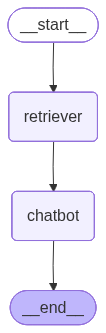

In [65]:
app